In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
bf.__version__

'2.0.12'

In [3]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=10
mu_prior_mean1=0
mu_prior_mean2=3
mu_prior_mean3=0.1
mu_prior_std=1
likelihood_std1=1
likelihood_std2=3
# student_df=5

In [4]:
def prior_1():
    mu=RNG.normal(loc=mu_prior_mean1,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def prior_2():
    mu=RNG.normal(loc=mu_prior_mean2,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def prior_3():
    mu=RNG.normal(loc=mu_prior_mean3,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)

def likelihood_1(mu):
    x=RNG.normal(loc=mu,scale=likelihood_std1,size=(num_obs,num_dims))
    return dict(x=x)
def likelihood_2(mu):
    x=RNG.normal(loc=mu,scale=likelihood_std2,size=(num_obs,num_dims))
    return dict(x=x)

simulator_1=bf.make_simulator([prior_1,likelihood_1])
simulator_2=bf.make_simulator([prior_2,likelihood_1])
simulator_3=bf.make_simulator([prior_1,likelihood_2])
simulator_4=bf.make_simulator([prior_3,likelihood_1])
simulator=bf.simulators.ModelComparisonSimulator(
    simulators=[simulator_1,simulator_2,simulator_3,simulator_4],
    use_mixed_batches=True,
    )


In [5]:
data = simulator.sample(100)
for key, value in data.items():
    print(key + " shape:", np.array(value).shape)

mu shape: (100, 20)
x shape: (100, 10, 20)
model_indices shape: (100, 4)


In [6]:
# adapter 
adapter = (bf.Adapter()
           .as_set("x")
           .convert_dtype("float64", "float32")
           .rename('x', 'summary_variables')
           .rename('model_indices', 'inference_variables')
                )

In [7]:
# networks
summary_network = bf.networks.DeepSet(summary_dim=3*4)
classifier_network = bf.networks.MLP()

In [8]:
approximator = bf.approximators.ModelComparisonApproximator(
            num_models=4,
            classifier_network=classifier_network,
            summary_network=summary_network,
            adapter=adapter,
            standardize="all",  
        )

In [9]:
epochs=100
batch_size=100
num_batches_per_epoch=200
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [10]:
history = approximator.fit(simulator=simulator,adapter=adapter,
                           epochs=epochs,batch_size=batch_size,num_batches=num_batches_per_epoch,)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 12 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - cross_entropy/inference_cross_entropy: 0.5367 - loss: 0.5367
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - cross_entropy/inference_cross_entropy: 0.4143 - loss: 0.4143
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - cross_entropy/inference_cross_entropy: 0.3327 - loss: 0.3327
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - cross_entropy/inference_cross_entropy: 0.3379 - loss: 0.3379
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - cross_entropy/inference_cross_entropy: 0.4306 - loss: 0.4306
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - cross_entropy/inference_cross_entropy: 0.3466 - loss: 0.3466
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - cross_entropy/inference_cross_entropy: 0.3325 - loss: 0.3325
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - cross_entropy/inference_cross_entropy: 0.3815 - loss: 0.3815
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - cross_en

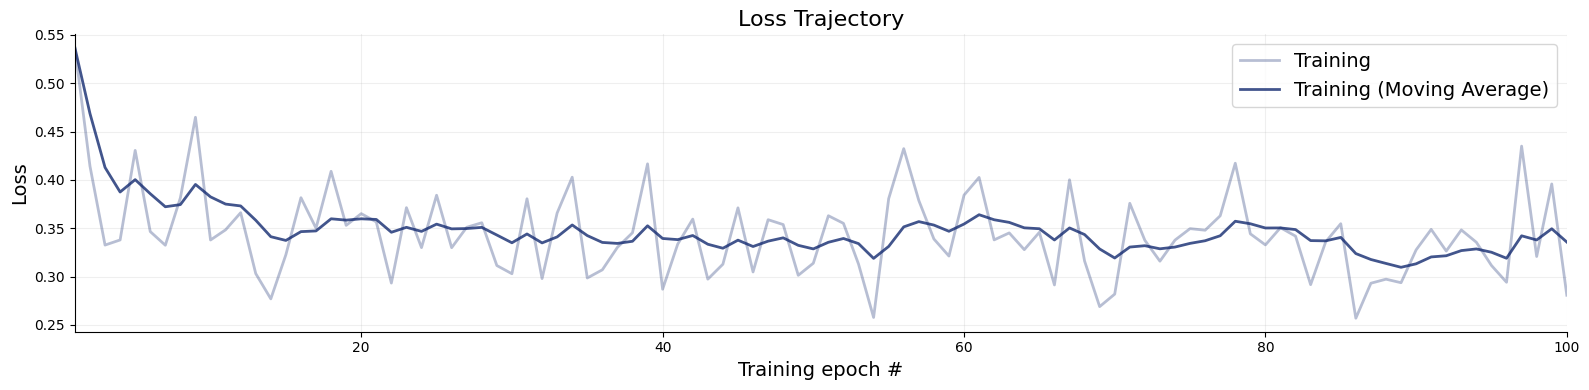

In [11]:
f=bf.diagnostics.plots.loss(history)

In [12]:
val_df=simulator.sample(5000)
pred_models = approximator.predict(conditions=val_df, probs=True)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


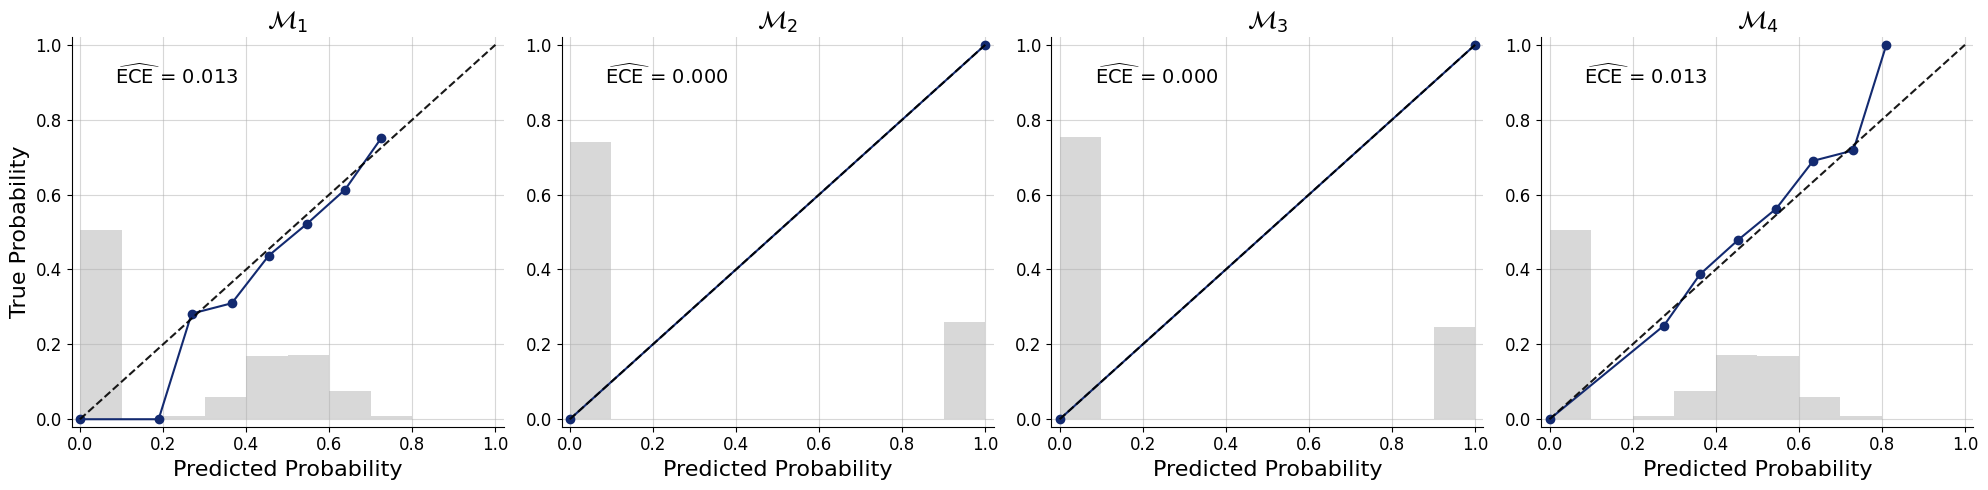

In [13]:
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$",r"$\mathcal{M}_4$"],
)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


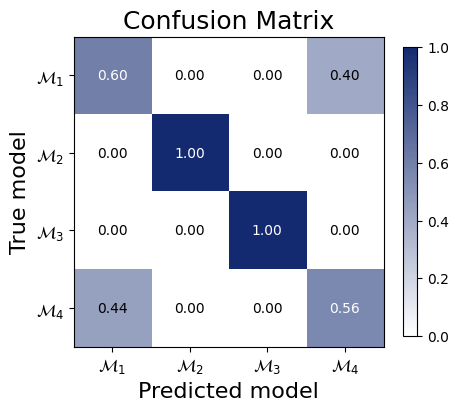

In [14]:
f = bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$",r"$\mathcal{M}_4$"],
    normalize="true",
)

In [15]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "direct_s_20d_10n.keras"
filepath.parent.mkdir(exist_ok=True)
approximator.save(filepath=filepath)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


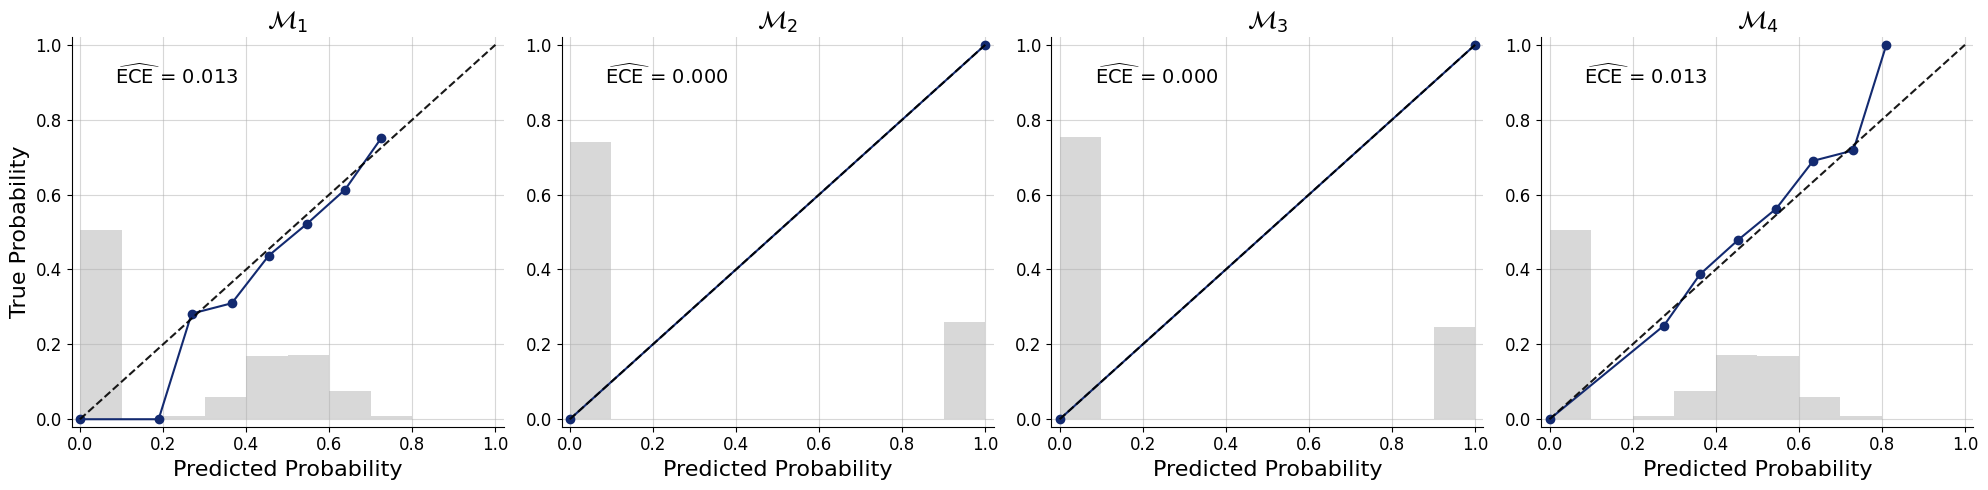

In [16]:
# Load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "direct_s_20d_10n.keras"
approximator = keras.saving.load_model(filepath)
pred_models = approximator.predict(conditions=val_df, probs=True)
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$",r"$\mathcal{M}_4$"],
)